<a href="https://colab.research.google.com/github/SufyAD/Langchain/blob/langchain-todo/rag_basic_advance_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -qU langchain langchain_community bs4 pypdf langchain_ollama langchain_core langchain_chroma

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 5.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.1/611.1 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

In [2]:
!pip install -qU langchain_google_genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 48.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-generativeai 0.8.4 requires google-ai-generativelanguage==0.6.15, but you have google-ai-generativelanguage 0.6.17 which is incompatible.


# Basic **RAG** Implementation

## **Step 1**: Data Ingestion/ Source Load for retrieval later

In [3]:
# Data Ingestion
from langchain_community.document_loaders import PyPDFLoader
path = '/content/attention.pdf'
loader = PyPDFLoader(path)
doc = loader.load()

#check if doc is loaded successfully or not
doc

[Document(metadata={'producer': '', 'creator': 'WPS Writer', 'creationdate': '2025-03-31T20:34:35+05:00', 'author': 'PC', 'comments': '', 'company': '', 'keywords': '', 'moddate': '2025-03-31T20:34:35+05:00', 'sourcemodified': "D:20250331203435+05'00'", 'subject': '', 'title': '', 'trapped': '/False', 'source': '/content/attention.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content="Attention is All You Need\nAttention in neural networks revolutionized NLP, yet the human brain’s selective\nfocus mirrors this mechanism. Transformers leverage self-attention to weigh token\nrelationships efficiently. Meanwhile, quantum entanglement suggests nature’s own\ninterconnected attention model. Shifting gears, consider stock markets—investor\nsentiment dictates trends, much like attention heads capturing context. Attention\ndeficit disorders challenge cognition, just as models struggle with overfitting.\nMeanwhile, black holes distort light paths, an extreme form of gravitational a

In [4]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
text_splitter=RecursiveCharacterTextSplitter(chunk_size=100,chunk_overlap=10)
documents=text_splitter.split_documents(doc)
documents[:10]

[Document(metadata={'producer': '', 'creator': 'WPS Writer', 'creationdate': '2025-03-31T20:34:35+05:00', 'author': 'PC', 'comments': '', 'company': '', 'keywords': '', 'moddate': '2025-03-31T20:34:35+05:00', 'sourcemodified': "D:20250331203435+05'00'", 'subject': '', 'title': '', 'trapped': '/False', 'source': '/content/attention.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Attention is All You Need'),
 Document(metadata={'producer': '', 'creator': 'WPS Writer', 'creationdate': '2025-03-31T20:34:35+05:00', 'author': 'PC', 'comments': '', 'company': '', 'keywords': '', 'moddate': '2025-03-31T20:34:35+05:00', 'sourcemodified': "D:20250331203435+05'00'", 'subject': '', 'title': '', 'trapped': '/False', 'source': '/content/attention.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Attention in neural networks revolutionized NLP, yet the human brain’s selective'),
 Document(metadata={'producer': '', 'creator': 'WPS Writer', 'creationdate': '2025-

## **Step 2**: Data Embedding
Transforming Text into **Numerical Vectors** and store in **vector DB**

In [5]:
# Note: You need langchain_ollama downloaded to run Ollama on your local-machine, thus, it is recommended to go with langchain_google_genai
# for practice
from langchain_ollama import OllamaEmbeddings
embeddings = OllamaEmbeddings(
    model="llama3",
)

In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from google.colab import userdata

embeddings = GoogleGenerativeAIEmbeddings(google_api_key=userdata.get('GEMINI_API_KEY'), model="models/embedding-001")

# Using Chroma DB and Google Gemini Embedding model

from langchain_chroma import Chroma
db = Chroma.from_documents(documents,embeddings)

In [7]:
query = "Attenion is related to NLP?"
retr_result = db.similarity_search(query)
display(retr_result[0].page_content)

'Attention in neural networks revolutionized NLP, yet the human brain’s selective'

# Advance **RAG Pipeline** Understanding
We are going to use RAG `chain` and `retrieval`
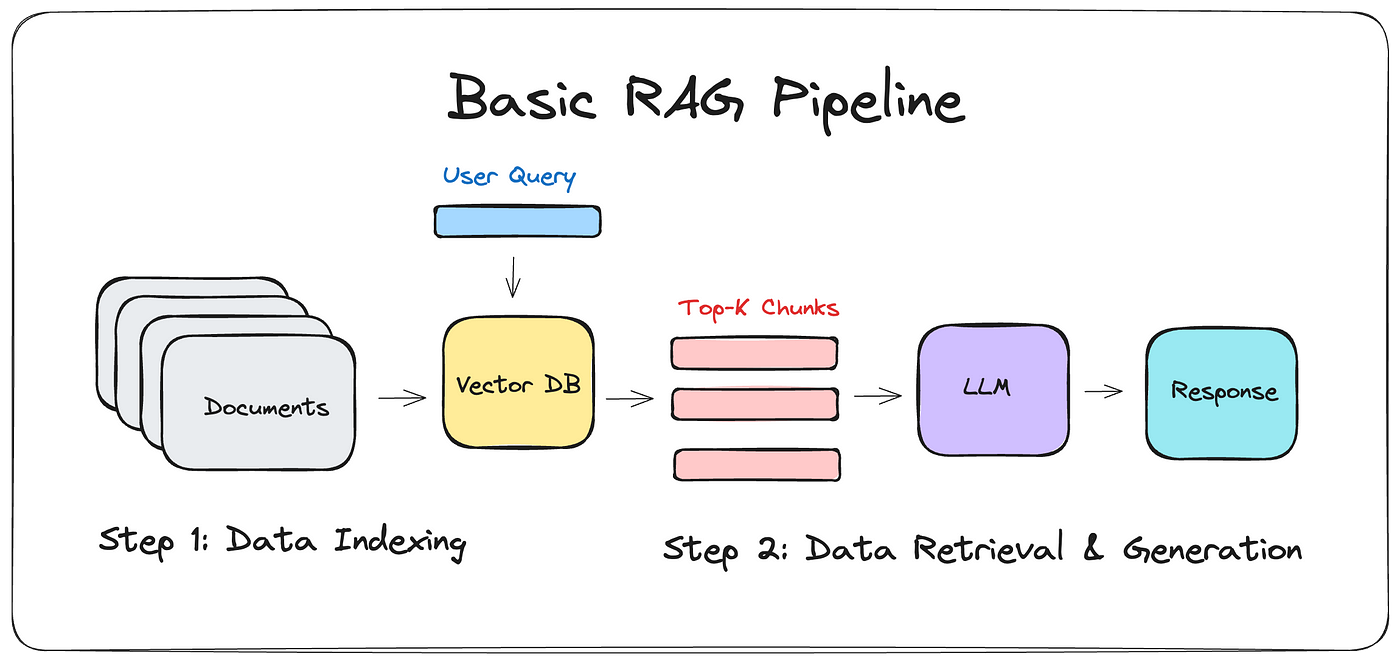

In [8]:
from langchain_community.document_loaders import PyPDFLoader
path = '/content/attention.pdf'
loader = PyPDFLoader(path)
doc = loader.load()

#check if doc is loaded successfully or not
doc

[Document(metadata={'producer': '', 'creator': 'WPS Writer', 'creationdate': '2025-03-31T20:34:35+05:00', 'author': 'PC', 'comments': '', 'company': '', 'keywords': '', 'moddate': '2025-03-31T20:34:35+05:00', 'sourcemodified': "D:20250331203435+05'00'", 'subject': '', 'title': '', 'trapped': '/False', 'source': '/content/attention.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content="Attention is All You Need\nAttention in neural networks revolutionized NLP, yet the human brain’s selective\nfocus mirrors this mechanism. Transformers leverage self-attention to weigh token\nrelationships efficiently. Meanwhile, quantum entanglement suggests nature’s own\ninterconnected attention model. Shifting gears, consider stock markets—investor\nsentiment dictates trends, much like attention heads capturing context. Attention\ndeficit disorders challenge cognition, just as models struggle with overfitting.\nMeanwhile, black holes distort light paths, an extreme form of gravitational a

In [9]:
!pip install -qU faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 42.9 MB/s eta 0:00:00


In [10]:
# Step 1: Data Ingestion
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain_community.vectorstores import FAISS

embeddings = GoogleGenerativeAIEmbeddings(google_api_key=userdata.get('GEMINI_API_KEY'), model="models/embedding-001")
db = FAISS.from_documents(documents,embeddings) # direct from docs

In [24]:
# Step 2: Adding an augmented LLM
from langchain_core.prompts import ChatPromptTemplate
prompt = ChatPromptTemplate.from_template("""
  Answer the following questions beatifully in a MARKDOWN format based only on the provided information and do not halucinate.
  Think step by step before providing a detailed/controversial/suspicious answer
  <context>
  {context}
  </context>
  <question>
   {input}
  </question>
""")
model = ChatGoogleGenerativeAI(google_api_key=userdata.get('GEMINI_API_KEY'), model='gemini-1.5-flash')

## Using langchain Chains and Retrieval
`create_stuff_documents_chain`

This chain takes a list of documents and formats them all into a prompt, then passes that prompt to an LLM. It passes ALL documents, so you should make sure it fits within the context window of the LLM you are using.

In [25]:
# Step 2a  ------- Create document chain to pass entire doc and prompt alongside to the llm
from langchain.chains.combine_documents.stuff import create_stuff_documents_chain
doc_chain = create_stuff_documents_chain(model, prompt)
doc_chain

RunnableBinding(bound=RunnableBinding(bound=RunnableAssign(mapper={
  context: RunnableLambda(format_docs)
}), kwargs={}, config={'run_name': 'format_inputs'}, config_factories=[])
| ChatPromptTemplate(input_variables=['context', 'input'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'input'], input_types={}, partial_variables={}, template='\n  Answer the following questions beatifully in a MARKDOWN format based only on the provided information and do not halucinate.\n  Think step by step before providing a detailed/controversial/suspicious answer\n  <context>\n  {context}\n  </context>\n  <question>\n   {input}\n  </question>\n'), additional_kwargs={})])
| ChatGoogleGenerativeAI(model='models/gemini-1.5-flash', google_api_key=SecretStr('**********'), client=<google.ai.generativelanguage_v1beta.services.generative_service.client.GenerativeServiceClient object at 0x7edf7e65a490>, default_metadata=())
| StrOu

In [26]:
# Step 2b: Create a retriever for the DB
retriever = db.as_retriever()

`create_retrieval_chain`

This chain takes in a user inquiry, which is then passed to the retriever to fetch relevant documents. Those documents (and original inputs) are then passed to an LLM to generate a response

In [27]:
# Step 2c: Create retrieval chain
from langchain.chains import create_retrieval_chain
chain = create_retrieval_chain(retriever, doc_chain)

## Invoke and test your retrieval chain using this command


```
chain.invoke({
  "role": "user", # optional
  "input": "you input in str here"})
```



In [30]:
resp = chain.invoke({
    "role": "user",
    "input": "What is attention?"
})

In [29]:
from IPython.display import Markdown, display

def display_markdown(text):
  display(Markdown(text))

display_markdown(resp['answer'])

Based solely on the provided text:

Attention is described as "the fabric of intelligence" and a key component of interconnected models.  The text uses the example of stock markets, where investor sentiment (analogous to attention heads capturing context) dictates trends.  Therefore, attention is presented as a mechanism for focusing on relevant information within a larger context, similar to how investors focus on key market indicators.